### ****Eigenfaces Face Recognition using PCA****

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from PIL import Image
import os

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("kasikrit/att-database-of-faces")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'att-database-of-faces' dataset.
Path to dataset files: /kaggle/input/att-database-of-faces


In [ ]:
import os
import numpy as np
from PIL import Image

data = []
labels = []

dataset_path = path   # ✅ IMPORTANT FIX

for person in os.listdir(dataset_path):
    person_path = os.path.join(dataset_path, person)

    if not os.path.isdir(person_path):
        continue

    for img_name in os.listdir(person_path):
        img_path = os.path.join(person_path, img_name)

        try:
            img = Image.open(img_path).convert('L')
            img = img.resize((64, 64))
            img = np.array(img).flatten()

            data.append(img)
            labels.append(person)

        except:
            pass

In [ ]:
import os

for person in os.listdir(dataset_path):
    person_path = os.path.join(dataset_path, person)

    print("Person:", person)
    print("Path:", person_path)

Person: s32
Path: /kaggle/input/att-database-of-faces/s32
Person: s39
Path: /kaggle/input/att-database-of-faces/s39
Person: s26
Path: /kaggle/input/att-database-of-faces/s26
Person: s20
Path: /kaggle/input/att-database-of-faces/s20
Person: s18
Path: /kaggle/input/att-database-of-faces/s18
Person: s25
Path: /kaggle/input/att-database-of-faces/s25
Person: s24
Path: /kaggle/input/att-database-of-faces/s24
Person: s14
Path: /kaggle/input/att-database-of-faces/s14
Person: s40
Path: /kaggle/input/att-database-of-faces/s40
Person: s27
Path: /kaggle/input/att-database-of-faces/s27
Person: s33
Path: /kaggle/input/att-database-of-faces/s33
Person: README
Path: /kaggle/input/att-database-of-faces/README
Person: s1
Path: /kaggle/input/att-database-of-faces/s1
Person: s11
Path: /kaggle/input/att-database-of-faces/s11
Person: s31
Path: /kaggle/input/att-database-of-faces/s31
Person: s35
Path: /kaggle/input/att-database-of-faces/s35
Person: s13
Path: /kaggle/input/att-database-of-faces/s13
Person: s1

In [ ]:
import numpy as np

X = np.array(data)
y = np.array(labels)

print(X.shape)
print(y.shape)

(400, 4096)
(400,)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=50)

X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier(n_neighbors=3)
model.fit(X_train_pca, y_train)

KNeighborsClassifier(n_neighbors=3)

In [ ]:
y_pred = model.predict(X_test_pca)

In [ ]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9375


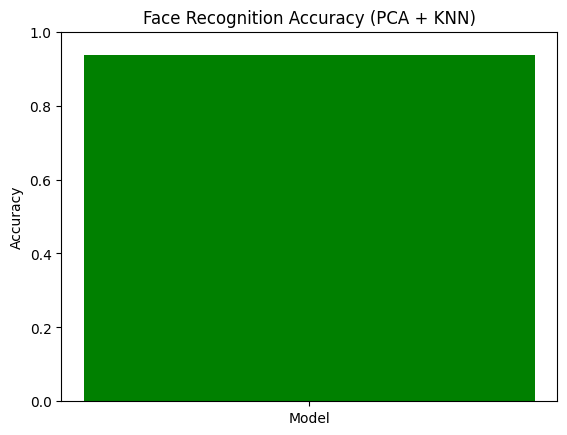

In [ ]:
import matplotlib.pyplot as plt

accuracy = 0.9375

plt.bar(["Model"], [accuracy], color="green")
plt.ylim(0, 1)
plt.title("Face Recognition Accuracy (PCA + KNN)")
plt.ylabel("Accuracy")
plt.show()

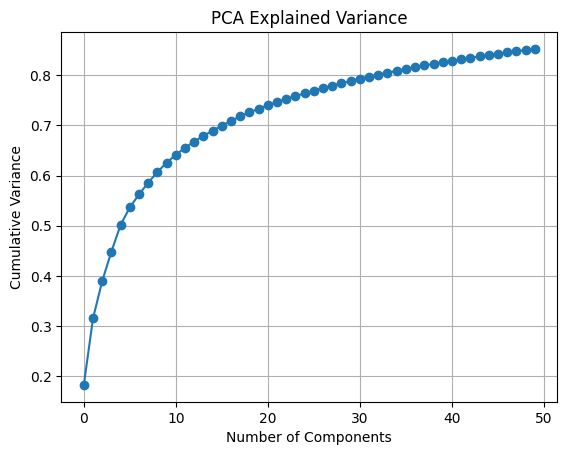

In [ ]:
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')    #har pca na kitni informaton rkhi ha or badh main unko add kr diya
plt.title("PCA Explained Variance")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Variance")
plt.grid()
plt.show()

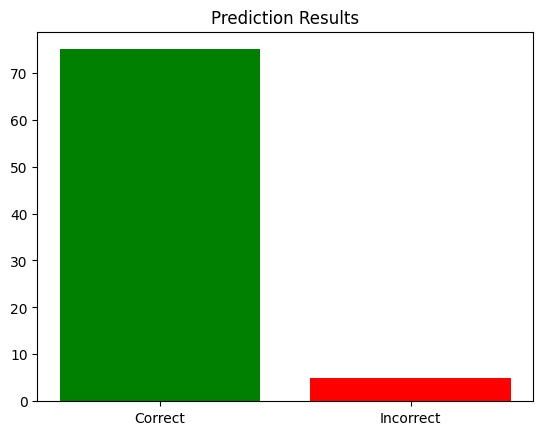

In [ ]:
import numpy as np

correct = np.sum(y_test == y_pred)
incorrect = len(y_test) - correct

plt.bar(["Correct", "Incorrect"], [correct, incorrect], color=["green", "red"])
plt.title("Prediction Results")
plt.show()

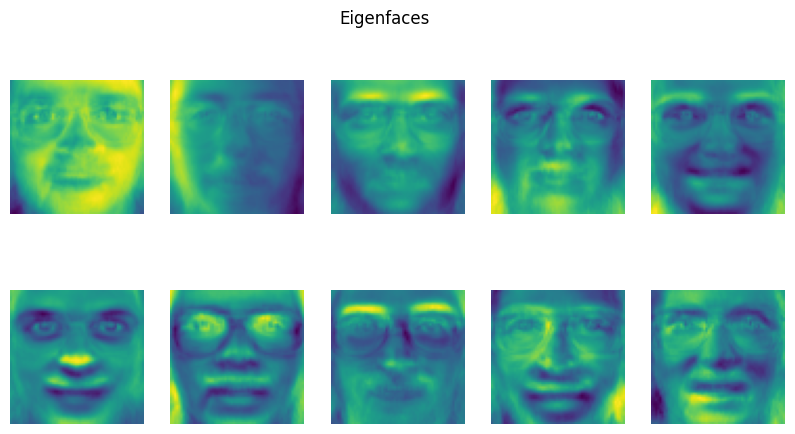

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(10,5))

for i, ax in enumerate(axes.flat):
    ax.imshow(pca.components_[i].reshape(64,64))
    ax.axis('off')

plt.suptitle("Eigenfaces")
plt.show()

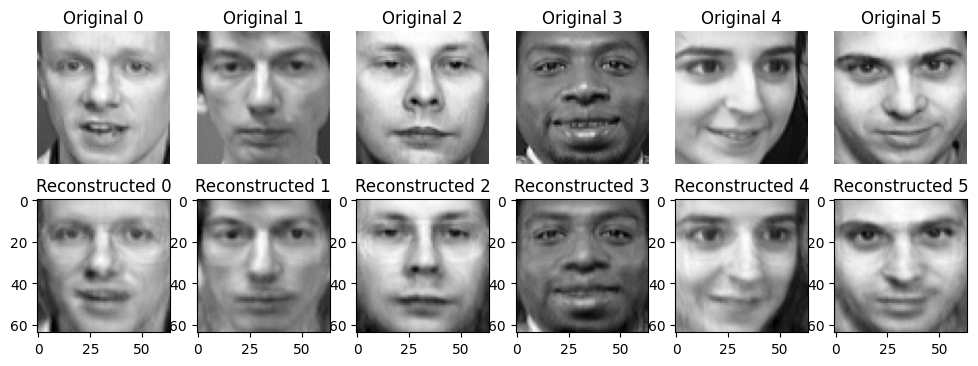

In [ ]:

fig, axes = plt.subplots(2, 6, figsize=(12,4))

for i in range(6):
    original = X[i]
    weights = pca.transform([original])
    reconstructed = pca.inverse_transform(weights)

    # Original face
    axes[0, i].imshow(original.reshape(64,64), cmap='gray')
    axes[0, i].set_title(f"Original {i}")
    axes[0, i].axis('off')

    # Reconstructed face
    axes[1, i].imshow(reconstructed.reshape(64,64), cmap='gray')
    axes[1, i].set_title(f"Reconstructed {i}")



In [ ]:
from google.colab import files
uploaded = files.upload()

Saving download.jfif to download (1).jfif


In [ ]:
from PIL import Image
import numpy as np

img_name = list(uploaded.keys())[0]

img = Image.open(img_name).convert('L')
img = img.resize((64, 64))

img = np.array(img).flatten()

img = img.reshape(1, -1)

In [ ]:
img_pca = pca.transform(img)

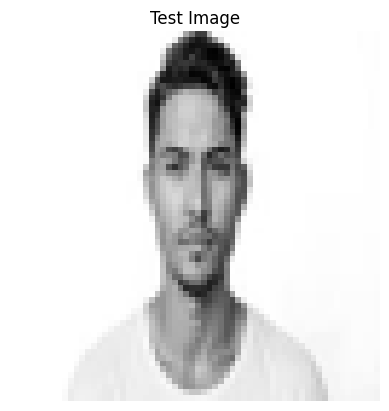

Predicted: s6


In [ ]:
import matplotlib.pyplot as plt

plt.imshow(img.reshape(64,64), cmap='gray')
plt.title("Test Image")
plt.axis('off')
plt.show()

print("Predicted:", prediction[0])